• ŷ=wx+b
• MSE = J(w, b) = 1/n ∑i=1-n (y –ŷ**2)

Steps:
1. Training:
    1. Initialize weight as zero
    2. Initialize bias as zero
2. Given a data point:
    1. Predict result by using ŷ=wx+b
    2. Calculate error
    3. Use gradient desecent to figure out new weight and bais values
    4. Repeat n times
3. Testing:
Given a data point:
    1. Put in the values from the data point into the equation ŷ=wx+b

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

In [16]:
class LinearRegression:
    def __init__(self,lr=0.001,n_iters=1000):
        self.lr=lr
        self.n_iters=n_iters
        self.weights=None
        self.bias=None

    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.weights=np.zeros(n_features)
        self.bias=0
        for _ in range(self.n_iters):
            y_pred=np.dot(X,self.weights)+self.bias

            dw=(1/n_samples)*np.dot(X.T,(y_pred-y))
            db=(1/n_samples)*np.sum(y_pred-y)

            self.weights=self.weights-self.lr*dw
            self.bias=self.bias-self.lr*db

    def predict(self,X):
        y_pred=np.dot(X,self.weights)+self.bias
        return y_pred

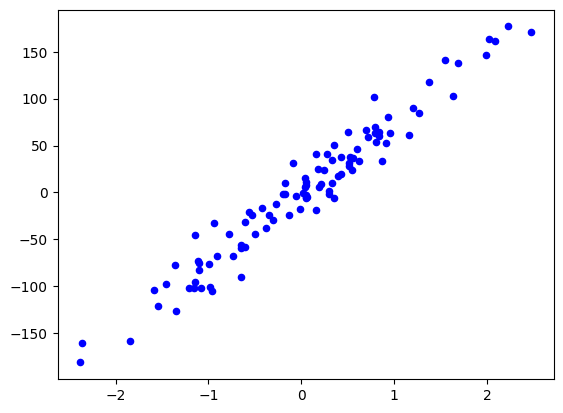

In [14]:
X,y=datasets.make_regression(n_samples=100,n_features=1, noise=20, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
plt.figure()
plt.scatter(X[:,0], y,color='b', marker='o', s=20)
plt.show()

In [39]:
reg=LinearRegression(lr=0.01)
reg.fit(X_train,y_train)
predictions=reg.predict(X_test)

def mse(y_test,predictions):
    return np.mean((y_test-predictions)**2)

mse_value=mse(y_test,predictions)
print(mse_value)


305.7719958301902


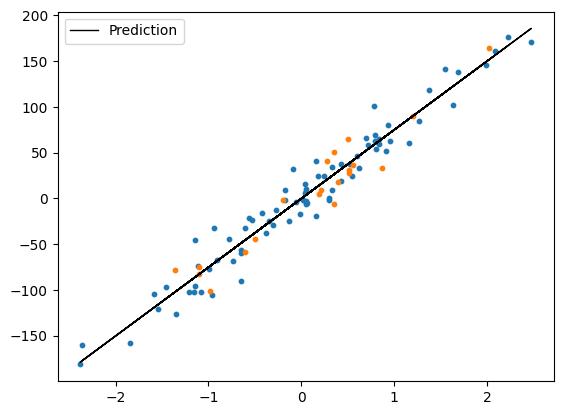

In [42]:
y_pred_line=reg.predict(X)
cmap=plt.get_cmap('viridis')
m1=plt.scatter(X_train, y_train, s=10)
m2=plt.scatter( X_test, y_test, s=10)
plt.plot(X,y_pred_line,color='black',linewidth=1, label='Prediction')
plt.legend()
plt.show()